### Simple code illustratating likelihood, posterior, and posterior normalization with sine-wave 

In [63]:
import numpy as np
import matplotlib.pyplot as plt

In [64]:
# creating artificial data
def data_func(x):
    return np.sin(x)


data=data_func

# some values of the data
data(0), data(1), data(3.14)

(np.float64(0.0),
 np.float64(0.8414709848078965),
 np.float64(0.0015926529164868282))

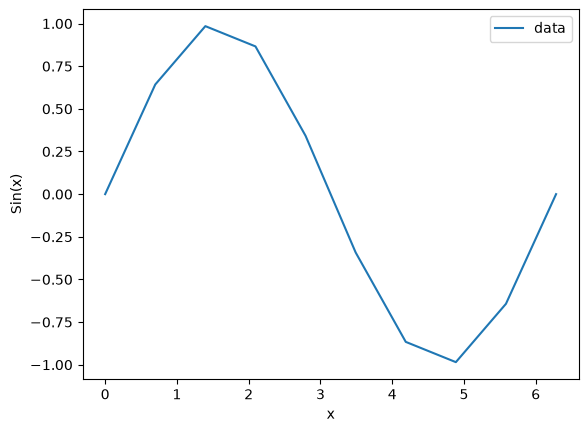

In [71]:
x=np.linspace(0,2*np.pi, 10)
data(x)

plt.plot(x, data(x), label='data')
plt.xlabel('x'); plt.ylabel('Sin(x)')
plt.legend(); plt.show()

In [4]:
## Let's make it more sophisticated

In [75]:
def data_func(t):
    return np.sin(omega*t)


data=data_func
omega=2*np.pi  #implies time-period = 1 seconds
# some values of the data
data(0), data(1), data(3.14)

(np.float64(0.0),
 np.float64(-2.4492935982947064e-16),
 np.float64(0.7705132427757901))

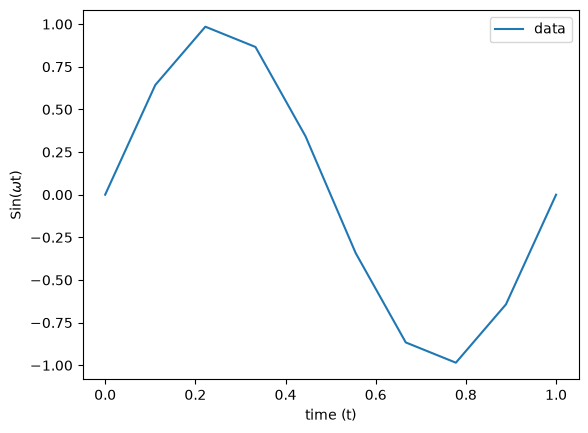

In [81]:
t=np.linspace(0,1,10)

plt.plot(t, data(t),label='data')
plt.xlabel('time (t)'); plt.ylabel('Sin($\omega$t)')
plt.legend(); plt.show()

In [82]:
def signal(omega,t):
    return np.sin(omega*t)

In [12]:
# Let's work in the zero-noise limit
# Noise, when accounted for, will be Gaussian with its mean around 0 and variance sigma
# For us variance sigma =0

def likelihood(omega, time, sigma=0.1):
    observed_data = data(time)
    signal_prediction = signal(omega,time)
    residual = observed_data - signal_prediction

    #after residual is computed
    likelihood_val = np.sqrt(1/(2*np.pi*sigma))*np.exp(-residual/(2*sigma**2))  

    # better to have in log-form
    log_likelihood_val = -0.5 * (((residual/sigma)**2) + np.log(2 * np.pi * sigma**2))

    return np.sum(log_likelihood_val)  
    
# runs over all possible t and finds how the residual and point-likelihood are, then adds them up

# to check
likelihood(2*np.pi, 0.4), likelihood(1*np.pi, 0.4), likelihood(6*np.pi, 0.4)

(np.float64(1.383646559789373),
 np.float64(-5.214654002715879),
 np.float64(-5.214654002715879))

/var/folders/8n/cd9qp505217fb25fc7mmvwhr0000gn/T/ipykernel_23412/700775023.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.show()


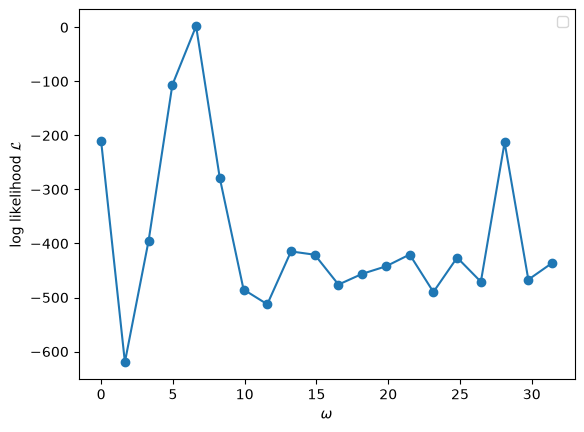

In [86]:
omega_values = np.linspace(0*np.pi,10*np.pi, 20) # since not sure which omega/signal going to fit the model well
time = t

ll = np.array([likelihood(w, time) for w in omega_values])
plt.plot(omega_values, ll, 'o-')
plt.xlabel('$\omega$'); plt.ylabel('log likelihood $\mathcal{L}$')
plt.legend(); plt.show()

In [20]:
log_prior = np.where((omega_values >= 0) & (omega_values <= 10*np.pi), 0.0, -np.inf)   # uniform prior between 0 and 10*np.pi
log_posterior = ll + log_prior

print(log_posterior)

[-211.1635344  -619.58135594 -394.65903674 -106.52977662    2.16852349
 -279.16741846 -485.16728266 -512.49890072 -414.68915563 -420.79993805
 -476.06777667 -456.1750245  -442.28947563 -420.43826593 -489.79379974
 -426.06213919 -470.84675081 -212.9485905  -466.94104135 -436.1635344 ]


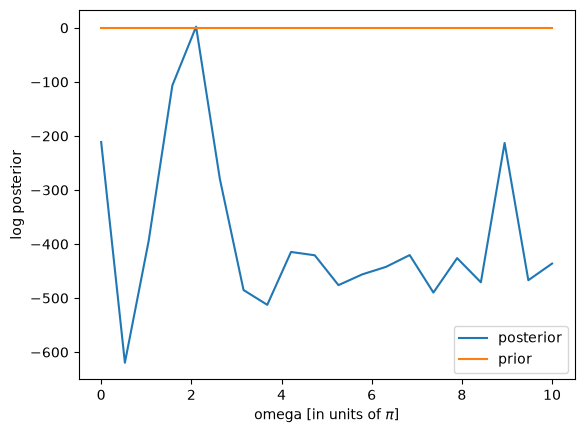

In [59]:
plt.plot(omega_values/(np.pi), log_posterior, label='posterior')
plt.plot(omega_values/(np.pi), log_prior, label='prior')
plt.xlabel('omega [in units of $\pi$]'); plt.ylabel('log posterior')
plt.legend(); plt.show()

In [43]:
# normalization, since sum log_posterior is not 1, we can normalize it

print(np.trapezoid(log_posterior, omega_values))

from scipy.special import logsumexp
log_Z = logsumexp(log_posterior) + np.log(np.diff(omega_values)[0])  #rectangular rule/product rule
post = np.exp(log_posterior - log_Z)

print(post)

print(np.trapezoid(post, omega_values))

-12262.38141200316
[1.35727601e-093 5.74198391e-271 2.76429288e-173 3.75432444e-048
 6.04788784e-001 3.97151842e-123 1.36254949e-212 1.83815183e-224
 5.52858444e-182 1.22669010e-184 1.21960031e-208 5.31532743e-200
 5.70095054e-194 1.76119349e-184 1.33377153e-214 6.35901642e-187
 2.25777285e-206 2.27734151e-094 1.12178160e-204 2.60861355e-191]
1.0


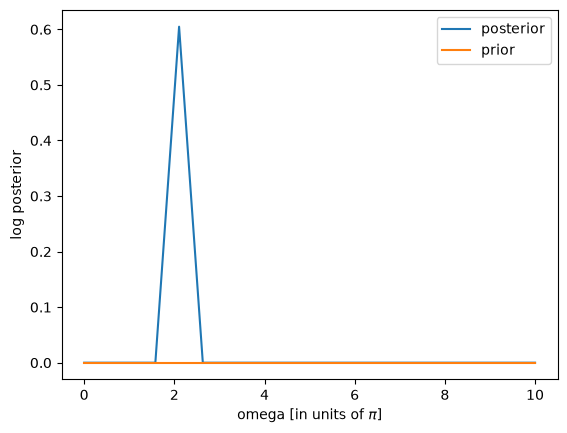

In [87]:
#plotting normalized posterior

plt.plot(omega_values/(np.pi), post, label='posterior')
plt.plot(omega_values/(np.pi), log_prior, label='prior')
plt.xlabel('omega [in units of $\pi$]'); plt.ylabel('log posterior')
plt.legend(); plt.show()